In [48]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU

In [49]:
#Configuration
sequence_length = 20
batch_size = 32
epochs = 300

input_features = ['Acc_X', 'Acc_Y', 'Acc_Z', 'Gyro_X', 'Gyro_Y', 'Gyro_Z', 'Tilt_X', 'Tilt_Y', 'Tilt_Z', 'Mag_X', 'Mag_Y', 'Mag_Z', 'Head', 'Temp', 'Press', 'delta_Alt']
#input_features = ['Acc_X', 'Acc_Y', 'Gyro_X', 'Gyro_Y', 'Gyro_Z', 'Head']
target_features = ['delta_Lng', 'delta_Lat']

input_shape = (sequence_length, len(input_features))

train_folder = 'data/train'
test_folder = 'data/test'
models_folder = 'models'

In [50]:
# Load and preprocess data from all CSV files in the 'train' folder
def load_data_from_folder(folder_path):
    sequences = []
    targets = []
    
    for file in os.listdir(folder_path):
        if file.endswith('.csv'):
            # Load the CSV file
            file_path = os.path.join(folder_path, file)
            data = pd.read_csv(file_path, delimiter=";")
            
            if len(data) < sequence_length:
                # Skip files with fewer rows than the sequence length
                continue
            
            # Normalize the input data (sensor data)
            input_data = data[input_features].values
            
            # Target data (deltas)
            target_data = data[target_features].values * 1000
            
            # Create sequences of input data and corresponding target deltas
            for i in range(len(data) - sequence_length):
                sequences.append(input_data[i:i + sequence_length])
                targets.append(target_data[i + sequence_length])

    return np.array(sequences), np.array(targets)

In [51]:
# Load data
X_train, y_train = load_data_from_folder(train_folder)
X_test, y_test = load_data_from_folder(test_folder)

In [58]:
model = Sequential()

model.add(GRU(64, input_shape=(sequence_length, len(input_features)), return_sequences=False))
model.add(Dense(32, activation='relu'))
model.add(Dense(2))

model.compile(optimizer='adam', loss='mean_squared_error')

history = model.fit(X_train, y_train, epochs=200, batch_size=32, validation_data=(X_test, y_test))

# model.evaluate(X_test, y_test)

model_name = f'gru.keras'
model.save(os.path.join(models_folder, model_name))

Epoch 1/500


InvalidArgumentError: Graph execution error:

Detected at node gradient_tape/compile_loss/mean_squared_error/sub/BroadcastGradientArgs defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "c:\Users\Usuario\anaconda3\envs\Quanvia\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>

  File "c:\Users\Usuario\anaconda3\envs\Quanvia\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance

  File "c:\Users\Usuario\anaconda3\envs\Quanvia\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start

  File "c:\Users\Usuario\anaconda3\envs\Quanvia\Lib\site-packages\tornado\platform\asyncio.py", line 205, in start

  File "c:\Users\Usuario\anaconda3\envs\Quanvia\Lib\asyncio\base_events.py", line 608, in run_forever

  File "c:\Users\Usuario\anaconda3\envs\Quanvia\Lib\asyncio\base_events.py", line 1936, in _run_once

  File "c:\Users\Usuario\anaconda3\envs\Quanvia

In [53]:
def plot_test_data(folder_path, model):
    sequences = []
    targets = []
    
    for file in os.listdir(folder_path):
        # Load the CSV file
        file_path = os.path.join(folder_path, file)
        data = pd.read_csv(file_path, delimiter=";")
        
        if len(data) < sequence_length:
            # Skip files with fewer rows than the sequence length
            continue
        
        # Normalize the input data (sensor data)
        input_data = data[input_features].values
        
        # Target data (deltas)
        target_data = data[target_features].values * 1000
        
        # Create sequences of input data and corresponding target deltas
        for i in range(len(data) - sequence_length):
            sequences.append(input_data[i:i + sequence_length])
            targets.append(target_data[i + sequence_length])
        
        model.layers[0].reset_states()

        y_pred = model.predict(np.array(sequences))
        y_test = np.array(targets)

        # Plot the predicted and true values
        fig, axs = plt.subplots(2, 2, figsize=(25, 20))
        
        # Plot actual vs predicted for delta_Lat
        axs[0, 0].plot(y_test[:, 0], label='Actual delta_Lng', color='blue')
        axs[0, 0].plot(y_pred[:, 0], label='Predicted delta_Lng', color='red')
        axs[0, 0].set_title('Actual vs Predicted delta_Lng')
        axs[0, 0].legend()

        # Plot actual vs predicted for delta_Lng
        axs[0, 1].plot(y_test[:, 1], label='Actual delta_Lat', color='blue')
        axs[0, 1].plot(y_pred[:, 1], label='Predicted delta_Lat', color='red')
        axs[0, 1].set_title('Actual vs Predicted delta_Lat')
        axs[0, 1].legend()

        #Scatter
        # Plot actual vs predicted for deltaY as scatter plot
        axs[1, 0].scatter(range(len(y_test[:, 0])), y_test[:, 0], label='Actual delta_Lng', color='blue')
        axs[1, 0].scatter(range(len(y_pred[:, 0])), y_pred[:, 0], label='Predicted delta_Lng', color='red')
        axs[1, 0].set_title('Actual vs Predicted delta_Lng')
        axs[1, 0].legend()

        axs[1, 1].scatter(range(len(y_test[:, 1])), y_test[:, 1], label='Actual delta_Lat', color='blue')
        axs[1, 1].scatter(range(len(y_pred[:, 1])), y_pred[:, 1], label='Predicted delta_Lat', color='red')
        axs[1, 1].set_title('Actual vs Predicted delta_Lat')
        axs[1, 1].legend()

        # Adjust layout
        fig.suptitle('Test file: ' + file, fontsize=16)
        plt.tight_layout()
        plt.show()


In [54]:
#plot_test_data(test_folder, model)

In [55]:
# Function to calculate real and predicted routes
def calculate_routes(file_path, sequence_length, input_features, model, verbose):
    data = pd.read_csv(file_path, delimiter=";")
    
    # Get the first point from 'Lat' and 'Lng'
    
    lng_real = [data.iloc[0]['Lng']]
    lat_real = [data.iloc[0]['Lat']]

    # Initialize real route
    for i in range(1, len(data)):
        # Get the deltas
        delta_lng = data.iloc[i]['delta_Lng']
        delta_lat = data.iloc[i]['delta_Lat']

        # Calculate next point based on the previous one
        lng_real.append(lng_real[-1] + delta_lng)
        lat_real.append(lat_real[-1] + delta_lat)
    
    # Now calculate the predicted route
    lng_pred = [data.iloc[0]['Lng']]
    lat_pred = [data.iloc[0]['Lat']]
    
    # Extract input data
    input_data = data[input_features].values
    print("\n\n")
    # Predict deltas and accumulate to form the predicted route
    for i in range(1, len(data)):
        # Prepare sequence for prediction
        if i >= sequence_length:
            X_test = input_data[i-sequence_length:i].reshape(1, sequence_length, len(input_features))
            delta_lng_pred, delta_lat_pred = model.predict(X_test, verbose=verbose)[0] / 1000

            print(f"Predicted deltas: {delta_lng_pred*1000}, {delta_lat_pred*1000}")
            print(f"Real deltas: {data.iloc[i]['delta_Lng']*1000}, {data.iloc[i]['delta_Lat']*1000}")

            lng_pred.append(lng_pred[-1] + delta_lng_pred)
            lat_pred.append(lat_pred[-1] + delta_lat_pred)

        else:
            # For first few rows, just use the real data
            lng_pred.append(lng_real[i])
            lat_pred.append(lat_real[i])

    
    return lng_real, lat_real, lng_pred, lat_pred

# Function to plot real and predicted routes for each test file
def plot_routes(test_folder, sequence_length, input_features, model, verbose):
    test_files = [f for f in os.listdir(test_folder) if f.endswith('.csv')]
    num_files = len(test_files)
    
    fig, axes = plt.subplots(nrows=num_files, ncols=1, figsize=(8, num_files * 6))
    
    if num_files == 1:
        axes = [axes]  #Ensure axes is iterable if there's only one file
    
    for idx, test_file in enumerate(test_files):
        file_path = os.path.join(test_folder, test_file)

        #model.layers[0].reset_states()
        
        lng_real, lat_real, lng_pred, lat_pred = calculate_routes(file_path, sequence_length, input_features, model, verbose)
        
        # Plot real and predicted points
        axes[idx].plot(lng_real, lat_real, color='blue', label='Real Route', marker='o', markersize=5)
        axes[idx].plot(lng_pred, lat_pred, color='red', label='Predicted Route', marker='o', markersize=5)
        
        axes[idx].set_title(f'Test File: {test_file}')
        axes[idx].set_xlabel('Lng')
        axes[idx].set_ylabel('Lat')
        axes[idx].legend()
    
    # Adjust layout
    plt.tight_layout()
    plt.show()

ValueError: too many values to unpack (expected 2)

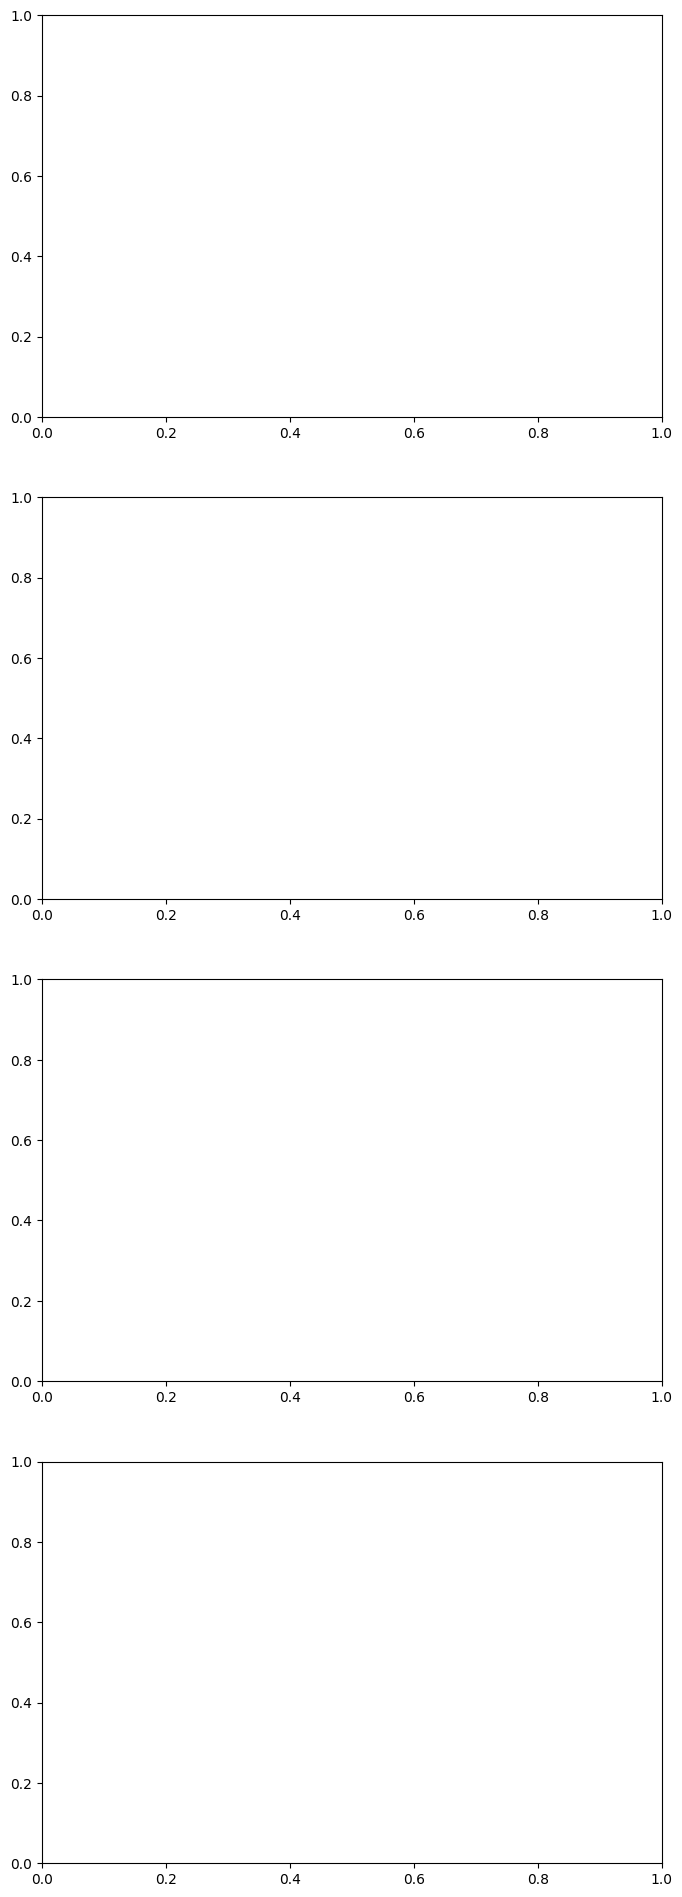

In [56]:
sequence_length = 20
verbose = 0 # Set to 1 to print more information about the training process
plot_routes(test_folder, sequence_length, input_features, model, verbose)